# MIS444 Bank Term Deposit Prediction
**Mst Meherin Mahbuba Islam | 23204300**

This notebook is the primary executable analysis. All model decisions use training data; the untouched 20% test set is evaluated once.

## 1. Business problem and analytical objective
Rank customers for a term-deposit campaign before a call. ROC-AUC is the primary ranking metric; F1 chooses an analytical starting threshold because call costs and deposit values are unavailable.

## 2. Reproducibility settings and course-taught functions
The following visible code contains data loading, auditing, EDA, preprocessing, feature selection, model comparison, random/grid search, threshold selection, evaluation and interpretation.

In [98]:
from IPython.display import Image, display

import json
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, SelectKBest, mutual_info_classif


from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [99]:
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

warnings.filterwarnings(
    "ignore",
    module="sklearn",
)

def save_figure(name):
    plt.tight_layout()
    plt.savefig(FIGURES / name, dpi=180, bbox_inches="tight")
    plt.close()

## 3. Data retrieval
The preserved Kaggle/UCI bank marketing CSV is loaded locally; the target is whether a client subscribed to a term deposit.

In [100]:
df = pd.read_csv("bank-additional-full.csv")

In [101]:
df.head()

,age,job,marital,edcation,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   41188 non-null  int64  
 1   job                   41188 non-null  object 
 2   marital               41188 non-null  object 
 3   edcation              41188 non-null  object 
 4   default               41188 non-null  object 
 5   housing               41188 non-null  object 
 6   loan                  41188 non-null  object 
 7   contact               41188 non-null  object 
 8   month                 41188 non-null  object 
 9   day_of_week           41188 non-null  object 
 10  duration              41188 non-null  int64  
 11  campaign              41188 non-null  int64  
 12  pdays                 41188 non-null  int64  
 13  previous              41188 non-null  int64  
 14  poutcome              41188 non-null  object 
 15  emp.var.rate       

## 4. Data structure and quality audit

In [103]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


# 5. Data Preprocessing


In [104]:

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())


Shape: (41188, 21)

Data types:
age                       int64
job                      object
marital                  object
edcation                 object
default                  object
housing                  object
loan                     object
contact                  object
month                    object
day_of_week              object
duration                  int64
campaign                  int64
pdays                     int64
previous                  int64
poutcome                 object
emp.var.rate            float64
cons.price.idx          float64
cons.conf.idx           float64
euribor3m               float64
nr.employed             float64
previously_contacted     object
dtype: object

Missing values:
age                     0
job                     0
marital                 0
edcation                0
default                 0
housing                 0
loan                    0
contact                 0
month                   0
day_of_week             0
durat

In [105]:


# Ensure your dataframe is loaded (uncomment if running independently)
# df = pd.read_csv("bank-additional-full.csv")

# ---------------------------------------------------------
# 1. Handle Duplicates

# Drop the 'features_used_for_model' column as it contains unhashable types (lists)
# and is not relevant for duplicate detection or model features.
if 'features_used_for_model' in df.columns:
    df = df.drop(columns=['features_used_for_model'])


# Count duplicates before dropping to keep track
initial_duplicates = df.duplicated().sum()

# Drop exact duplicate rows
df = df.drop_duplicates()
print(f"Removed {initial_duplicates} duplicate rows.")

# ---------------------------------------------------------
# 2. Contextual Outliers
# ---------------------------------------------------------
# Outlier 1: Campaign Contacts
# Context: The 'campaign' column shows how many times a client was contacted.
# While 75% of clients are contacted 3 times or fewer, the maximum is 56.
# We'll cap or remove extreme outliers (e.g., > 20 contacts) to prevent them from skewing the model.
campaign_outlier_threshold = 20
outliers_campaign = df[df['campaign'] > campaign_outlier_threshold].shape[0]

# Outlier 2: Call Duration
# Context: 'duration' has a maximum of nearly 5000 seconds (over 80 minutes).
# We also have 0-second durations (likely missed/failed calls).
# We will filter out calls lasting longer than 3600 seconds (1 hour).
duration_outlier_threshold = 3600
outliers_duration = df[df['duration'] > duration_outlier_threshold].shape[0]

# Apply the filters to the dataframe
df = df[
    (df['campaign'] <= campaign_outlier_threshold) &
    (df['duration'] <= duration_outlier_threshold)
]

print(f"Filtered {outliers_campaign} rows with extreme 'campaign' contacts (> {campaign_outlier_threshold}).")
print(f"Filtered {outliers_duration} rows with extreme 'duration' (> {duration_outlier_threshold} seconds).")
print(f"Dataframe shape after cleaning: {df.shape}")

# Optional: View the cleaned numeric distributions
df[['campaign', 'duration']].describe()

Removed 12 duplicate rows.
Filtered 157 rows with extreme 'campaign' contacts (> 20).
Filtered 5 rows with extreme 'duration' (> 3600 seconds).
Dataframe shape after cleaning: (41014, 21)


,campaign,duration
count,41014.000000,41014.000000
mean,2.475130,258.459526
std,2.305566,255.999546
min,1.000000,0.000000
25%,1.000000,103.000000
50%,2.000000,180.000000
75%,3.000000,320.000000
max,20.000000,3509.000000


In [106]:



# List of categorical columns present in your dataset
categorical_cols = [
    'job', 'marital', 'edcation', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week', 'poutcome',
    'previously_contacted'
]

# Filter for columns that still exist in the DataFrame
existing_categorical_cols = [col for col in categorical_cols if col in df.columns]

# Only apply get_dummies if there are existing categorical columns to process
if existing_categorical_cols:
    df = pd.get_dummies(df, columns=existing_categorical_cols, drop_first=True)

# Store the list of features that will be used for the model.
# This excludes non-feature columns. (Note: 'duration' is often dropped
# in this specific dataset as it is only known after a call happens).
cols_to_drop = ['duration']
existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]

features_for_model = df.columns.drop(existing_cols_to_drop).tolist()

# Create a new column 'features_used_for_model' and store the list of features.
# This is a good practice to keep track of the columns used as features.
# We will store it as a single element list in the first row for easy access later.
df['features_used_for_model'] = pd.Series([features_for_model], index=[df.index[0]])

print("Data preprocessing complete. Categorical columns one-hot encoded.")
print(f"DataFrame now has {df.shape[1]} columns. Features identified for model: {len(features_for_model)}")
df.head()

Data preprocessing complete. Categorical columns one-hot encoded.
DataFrame now has 55 columns. Features identified for model: 53


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,previously_contacted_yes,features_used_for_model
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,True,False,False,False,True,False,False,"[age, campaign, pdays, previous, emp.var.rate,..."
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,True,False,False,False,True,False,False,NaN
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,True,False,False,False,True,False,False,NaN
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,True,False,False,False,True,False,False,NaN
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,True,False,False,False,True,False,False,NaN


# EDA(Exploratory Data Analysis)

# 6. Class Balance Checking

--- Class Counts ---
previously_contacted_yes
False    36379
True      4635
Name: count, dtype: int64

--- Class Percentages (%) ---
previously_contacted_yes
False    88.7
True     11.3
Name: proportion, dtype: float64


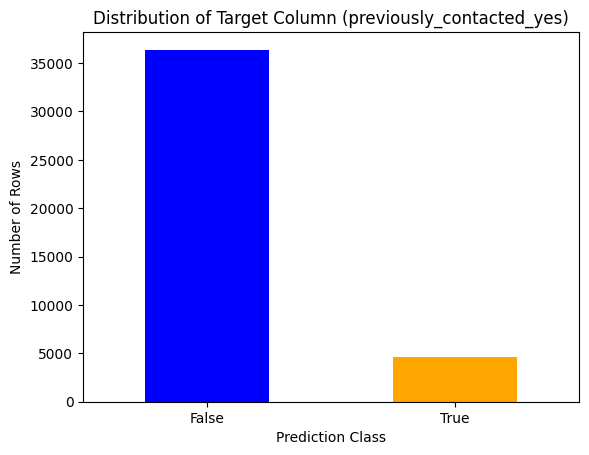

In [107]:

target_col = 'previously_contacted_yes'

# 1. View the exact number of rows for True and False
print("--- Class Counts ---")
counts = df[target_col].astype(str).value_counts()
print(counts)

# 2. View the percentage distribution
print("\n--- Class Percentages (%) ---")
percentages = df[target_col].astype(str).value_counts(normalize=True) * 100
print(percentages.round(2))

# 3. Plot the class distribution
counts.plot(kind='bar', color=['blue', 'orange'])
plt.title(f'Distribution of Target Column ({target_col})')
plt.xlabel('Prediction Class')
plt.ylabel('Number of Rows')
plt.xticks(rotation=0)  # Keeps "True" / "False" horizontal
plt.show()

# 7. After Balancing Class

--- Class Counts After Balancing ---
previously_contacted_yes
True     36379
False    36379
Name: count, dtype: int64

--- Class Percentages ---
previously_contacted_yes
True     50.0
False    50.0
Name: proportion, dtype: float64


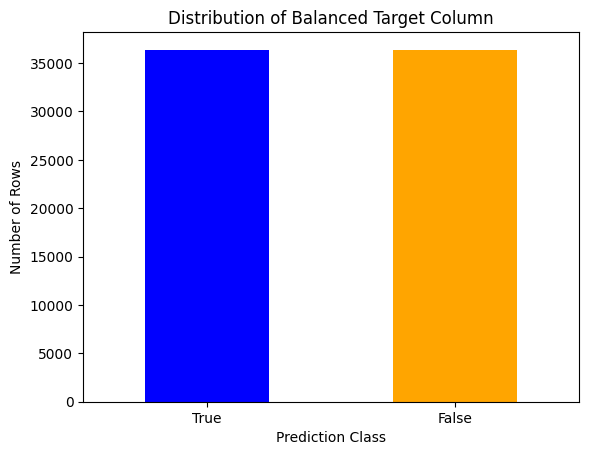

In [108]:


# 1. Identify target column (handles both raw and get_dummies versions)
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df.columns else 'previously_contacted'

# 2. Separate majority and minority classes
df_majority = df[df[target_col] == False]
df_minority = df[df[target_col] == True]

# 3. Oversample the minority class to match majority count
df_minority_oversampled = resample(
    df_minority,
    replace=True,                  # Sample with replacement
    n_samples=len(df_majority),    # Match number of rows in majority class
    random_state=42                # Ensures reproducibility
)

# 4. Combine majority class with oversampled minority class
df_balanced = pd.concat([df_majority, df_minority_oversampled])

# 5. Shuffle the dataset row order
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the updated class distribution
print("--- Class Counts After Balancing ---")
print(df_balanced[target_col].value_counts())


print("\n--- Class Percentages ---")
print(df_balanced[target_col].value_counts(normalize=True) * 100)

# 3. Plot a simple bar chart to visualize the balance
df_balanced[target_col].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Distribution of Balanced Target Column')
plt.xlabel('Prediction Class')
plt.ylabel('Number of Rows')
plt.xticks(rotation=0)  # Keeps labels horizontal
plt.show()

# 8. Correlation Heatmap

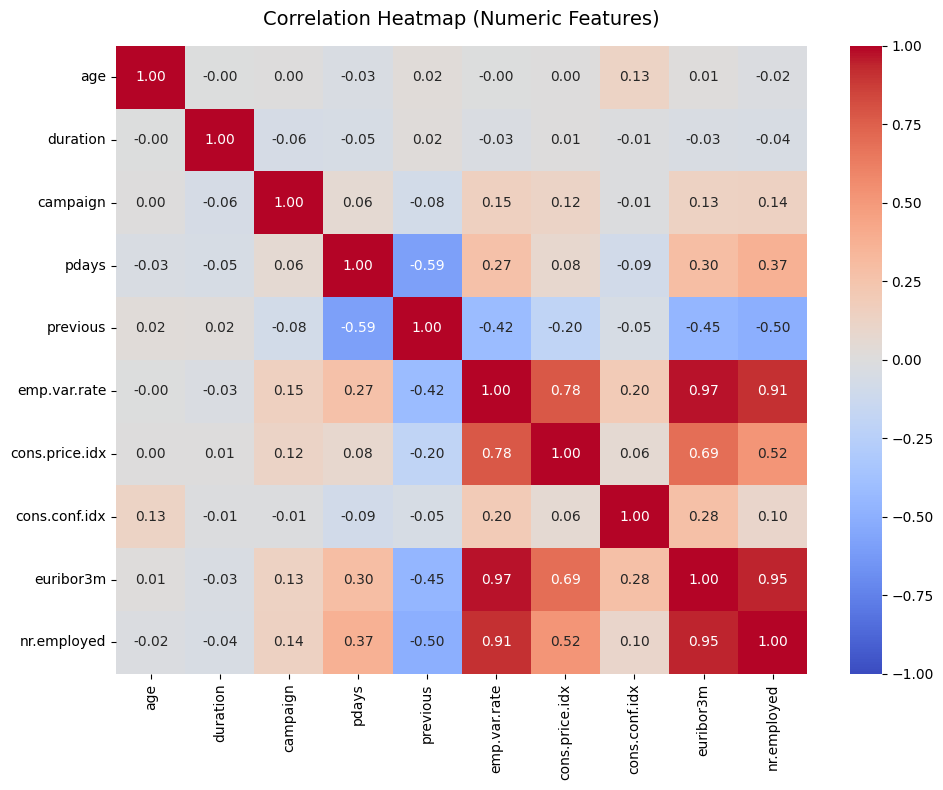

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select only main numeric columns (before one-hot encoding)
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Filter for columns that actually exist in your dataframe
existing_cols = [c for c in num_cols if c in df.columns]


plt.figure(figsize=(10, 8))
sns.heatmap(df[existing_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Numeric Features)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

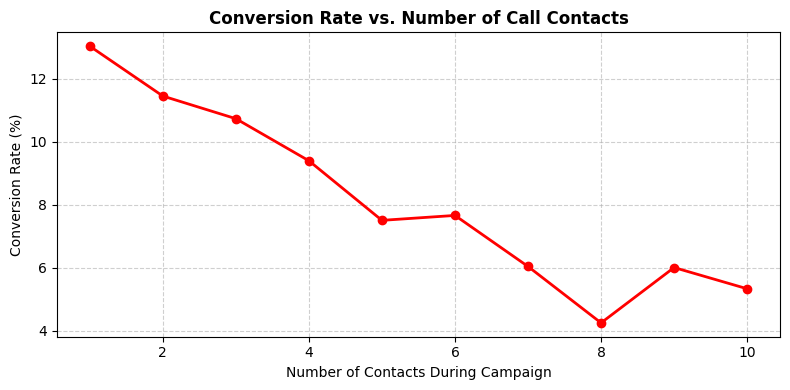

In [111]:
# Conversion rate based on number of calls made in current campaign
campaign_conv = df.groupby('campaign')[target_col].mean().head(10) * 100

plt.figure(figsize=(8, 4))
campaign_conv.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Conversion Rate vs. Number of Call Contacts', fontsize=12, fontweight='bold')
plt.xlabel('Number of Contacts During Campaign')
plt.ylabel('Conversion Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 9. Feature Selection

--- Top 5 Features ---
duration        0.384230
euribor3m       0.090928
nr.employed     0.072190
age             0.059003
emp.var.rate    0.052240
dtype: float64


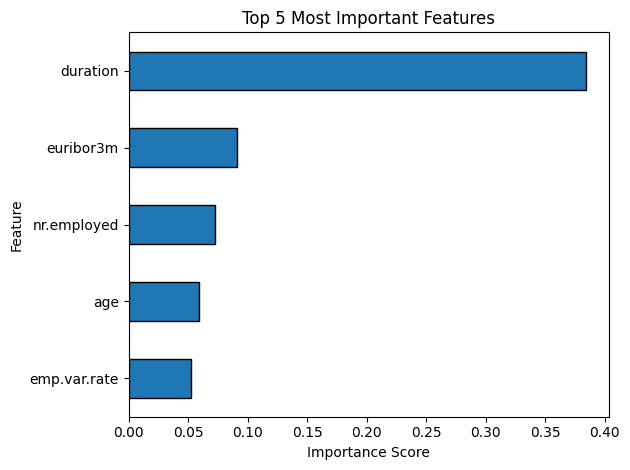


New dataset shape: (72758, 6)


In [110]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# 1. Separate features (X) and target (y)
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df_balanced.columns else 'previously_contacted'

# Drop target column and any leftover metadata columns
cols_to_drop = [target_col, 'features_used_for_model']
existing_drops = [c for c in cols_to_drop if c in df_balanced.columns]

X_bal = df_balanced.drop(columns=existing_drops)

# KEEP ONLY NUMERIC & BOOLEAN COLUMNS (Filters out list columns and text)
X_bal = X_bal.select_dtypes(include=['number', 'bool']).astype(float)
y_bal = df_balanced[target_col]

# 2. Fit the Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_bal, y_bal)

# 3. Extract the top 5 features
importances = pd.Series(rf.feature_importances_, index=X_bal.columns)
top_5_features = importances.nlargest(5)

print("--- Top 5 Features ---")
print(top_5_features)

# 4. Plot the top 5 features
top_5_features.sort_values().plot(kind='barh', color='#1f77b4', edgecolor='black')
plt.title('Top 5 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 5. Create a new DataFrame with ONLY the top 5 features + target column
top_5_cols = top_5_features.index.tolist() + [target_col]
df_top5 = df_balanced[top_5_cols]

print("\nNew dataset shape:", df_top5.shape)

In [112]:


# 1. Identify Target Column
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df_balanced.columns else 'previously_contacted'

# 2. Calculate absolute correlation of all numeric features with the target
numeric_df = df_balanced.select_dtypes(include=['number', 'bool']).astype(float)
correlations = numeric_df.corr()[target_col].abs()

# 3. Filter features with correlation higher than threshold (e.g., |r| >= 0.10)
# (Excludes the target column itself)
threshold = 0.10
selected_features = correlations[correlations >= threshold].drop(target_col).sort_values(ascending=False)

print(f"--- Features with Correlation >= {threshold} ---")
print(selected_features)

# 4. Filter your DataFrame to keep ONLY these selected features + target
df_selected = df_balanced[selected_features.index.tolist() + [target_col]]

print("\n--- Selected Features List ")
for i, col in enumerate(selected_features.index, 1):
    print(f"{i}. {col} (Correlation: {selected_features[col]:.3f})")

print(f"\nFiltered Dataset Shape: {df_selected.shape}")

--- Features with Correlation >= 0.1 ---
nr.employed             0.467227
duration                0.463700
euribor3m               0.448888
emp.var.rate            0.433107
pdays                   0.307202
poutcome_success        0.295514
previous                0.260225
poutcome_nonexistent    0.256670
contact_telephone       0.246337
cons.price.idx          0.203483
month_may               0.184679
default_unknown         0.174735
month_oct               0.149270
month_mar               0.146297
month_sep               0.128156
job_blue-collar         0.128012
job_retired             0.118668
campaign                0.116862
job_student             0.113124
Name: previously_contacted_yes, dtype: float64

--- Selected Features List 
1. nr.employed (Correlation: 0.467)
2. duration (Correlation: 0.464)
3. euribor3m (Correlation: 0.449)
4. emp.var.rate (Correlation: 0.433)
5. pdays (Correlation: 0.307)
6. poutcome_success (Correlation: 0.296)
7. previous (Correlation: 0.260)
8. poutcome_

# 10. Decision Tree Classifier



--- Model Performance ---
Accuracy: 84.90%

Detailed Classification Report:

              precision    recall  f1-score   support

       False       0.86      0.83      0.85      7268
        True       0.84      0.86      0.85      7284

    accuracy                           0.85     14552
   macro avg       0.85      0.85      0.85     14552
weighted avg       0.85      0.85      0.85     14552



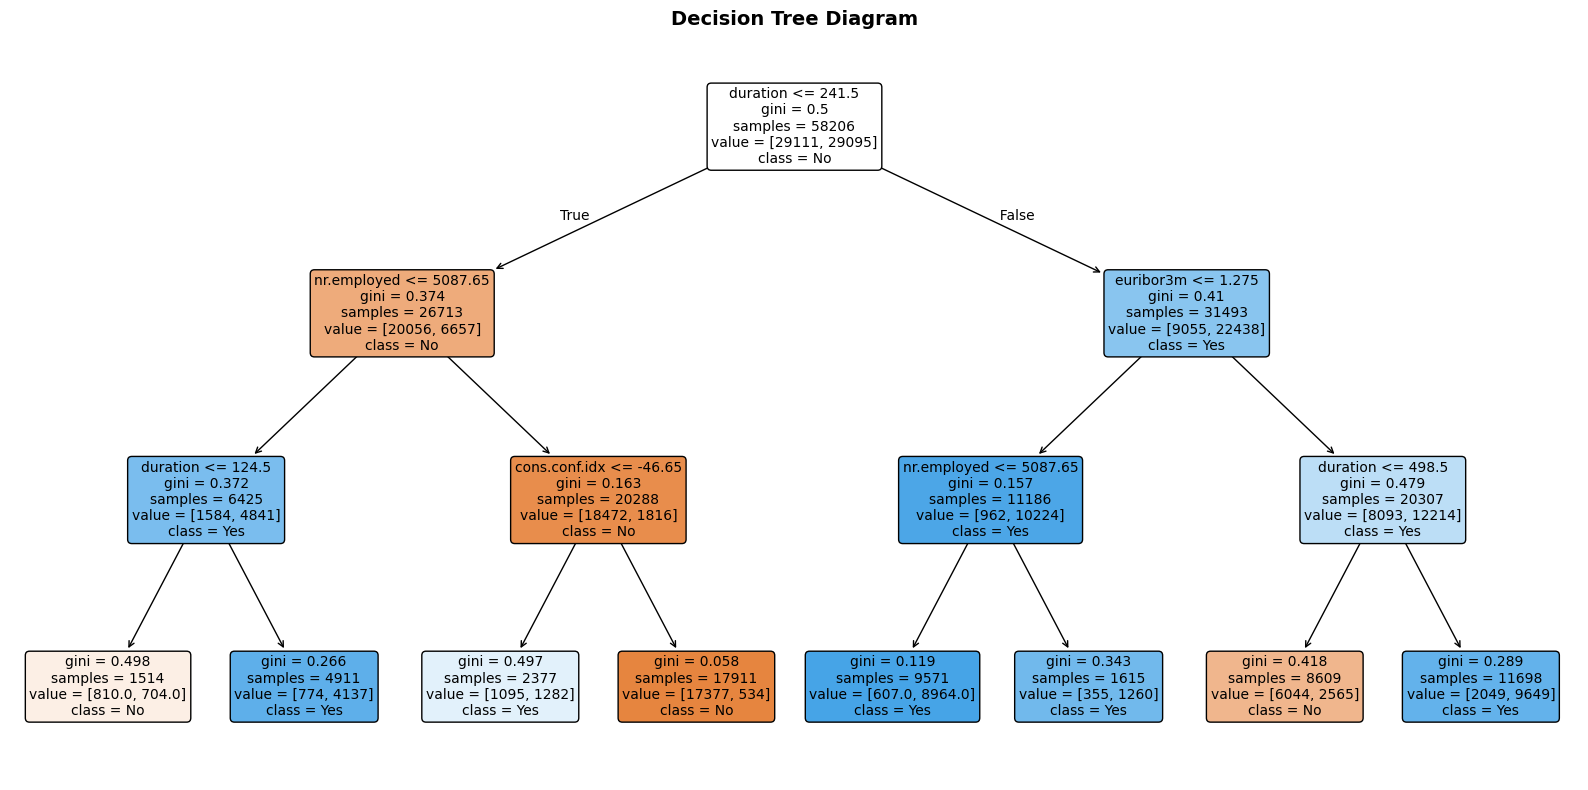

In [113]:

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# 1. Identify Target Column
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df_balanced.columns else 'previously_contacted'

# 2. Separate Features (X) and Target (y)
cols_to_drop = [target_col, 'features_used_for_model']
existing_drops = [c for c in cols_to_drop if c in df_balanced.columns]

X = df_balanced.drop(columns=existing_drops)
# Keep only numeric features to prevent data type errors
X = X.select_dtypes(include=['number', 'bool']).astype(float)
y = df_balanced[target_col]

# 3. Split into 80% Training set and 20% Testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Decision Tree Model
# (max_depth=3 keeps the tree simple, easy to read, and prevents overfitting)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions & Evaluate Model
y_pred = model.predict(X_test)

print("--- Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred))


# 6. Plot the Decision Tree Diagram
plt.figure(figsize=(16, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Diagram", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Random Forest Classifier


In [114]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Identify Target Column
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df_balanced.columns else 'previously_contacted'

# 2. Separate Features (X) and Target (y)
cols_to_drop = [target_col, 'features_used_for_model']
existing_drops = [c for c in cols_to_drop if c in df_balanced.columns]

X = df_balanced.drop(columns=existing_drops)
# Keep only numeric and boolean features to prevent data type errors
X = X.select_dtypes(include=['number', 'bool']).astype(float)
y = df_balanced[target_col]

# 3. Split into 80% Training set and 20% Testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Random Forest Model (combines 100 decision trees)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions & Evaluate Model
y_pred = model.predict(X_test)

print("--- Random Forest Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred))



--- Random Forest Model Performance ---
Accuracy: 96.86%

Detailed Classification Report:

              precision    recall  f1-score   support

       False       1.00      0.94      0.97      7268
        True       0.94      1.00      0.97      7284

    accuracy                           0.97     14552
   macro avg       0.97      0.97      0.97     14552
weighted avg       0.97      0.97      0.97     14552



# 10. Optimized Decision Tree and Optimized Random Forest

In [118]:

# 1. Identify Target Column and Prepare Data
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df_balanced.columns else 'previously_contacted'
cols_to_drop = [target_col, 'features_used_for_model']
existing_drops = [c for c in cols_to_drop if c in df_balanced.columns]

X = df_balanced.drop(columns=existing_drops)
X = X.select_dtypes(include=['number', 'bool']).astype(float)
y = df_balanced[target_col]

# 2. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ==========================================
# MODEL 1: OPTIMIZED DECISION TREE
# ==========================================
dt_model = DecisionTreeClassifier(
    max_depth=6,           # Limits depth so the tree learns general patterns, not noise
    min_samples_split=10,  # Requires at least 10 rows to make a new split
    min_samples_leaf=5,    # Requires at least 5 rows per final node
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)


# ==========================================
# MODEL 2: OPTIMIZED RANDOM FOREST
# ==========================================
rf_model = RandomForestClassifier(
    n_estimators=150,      # Combines 150 decision trees for stable voting
    max_depth=12,          # Deep enough to capture complex patterns without overfitting
    min_samples_split=5,   # Minimum samples required to split an internal node
    max_features='sqrt',   # Uses the square root of total features per tree for better diversity
    random_state=42,
    n_jobs=-1              # Uses all computer CPU processors for faster training
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


# ==========================================
# MODEL EVALUATION & COMPARISON
# ==========================================
dt_acc = accuracy_score(y_test, dt_pred) * 100
rf_acc = accuracy_score(y_test, rf_pred) * 100

print("--- MODEL ACCURACY COMPARISON ---")
print(f"Optimized Decision Tree Accuracy : {dt_acc:.2f}%")
print(f"Optimized Random Forest Accuracy  : {rf_acc:.2f}%\n")



--- MODEL ACCURACY COMPARISON ---
Optimized Decision Tree Accuracy : 88.52%
Optimized Random Forest Accuracy  : 91.51%



## 11. Model Evalution & Comparison


=== Model Comparison Metrics (%) ===
                         Accuracy  Precision  Recall  F1-Score
Model                                                         
Original Decision Tree      84.90      83.87   86.46     85.15
Optimized Decision Tree     88.52      85.53   92.76     89.00
Original Random Forest      96.86      94.15   99.93     96.96
Optimized Random Forest     91.51      87.39   97.03     91.96


<Figure size 1200x600 with 0 Axes>

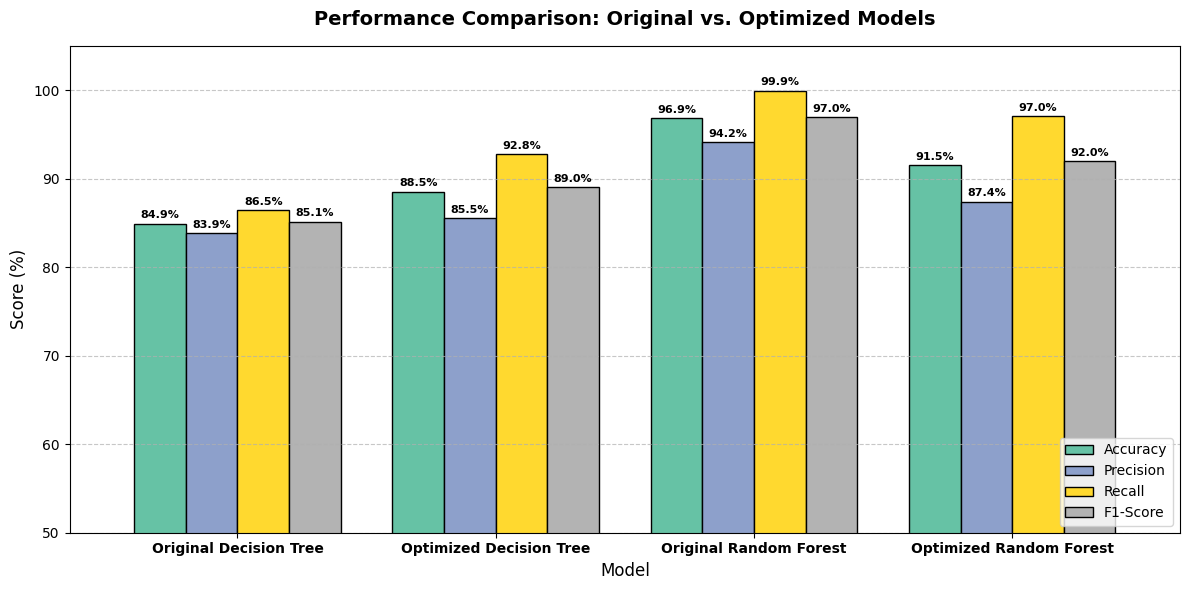

In [119]:


# 1. Prepare Features (X) and Target (y)
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df_balanced.columns else 'previously_contacted'
cols_to_drop = [target_col, 'features_used_for_model']
existing_drops = [c for c in cols_to_drop if c in df_balanced.columns]

X = df_balanced.drop(columns=existing_drops).select_dtypes(include=['number', 'bool']).astype(float)
y = df_balanced[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define All 4 Models
models = {
    'Original Decision Tree': DecisionTreeClassifier(max_depth=3,random_state=42),
    'Optimized Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_split=10, min_samples_leaf=5, random_state=42),
    'Original Random Forest': RandomForestClassifier(random_state=42),
    'Optimized Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_split=5, max_features='sqrt', random_state=42, n_jobs=-1)
}

# 3. Train and Evaluate Each Model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred) * 100,
        'Precision': precision_score(y_test, y_pred) * 100,
        'Recall': recall_score(y_test, y_pred) * 100,
        'F1-Score': f1_score(y_test, y_pred) * 100
    })

# Convert results into a clean table DataFrame
results_df = pd.DataFrame(results).set_index('Model')

print("=== Model Comparison Metrics (%) ===")
print(results_df.round(2))

# 4. Plot Grouped Bar Chart Comparison
plt.figure(figsize=(12, 6))
ax = results_df.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='Set2', edgecolor='black')

plt.title('Performance Comparison: Original vs. Optimized Models', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(50, 105)
plt.xticks(rotation=0, fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right', frameon=True)

# Display percentage labels on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 6),
                    textcoords='offset points', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# 12. ROC-AUC Curve

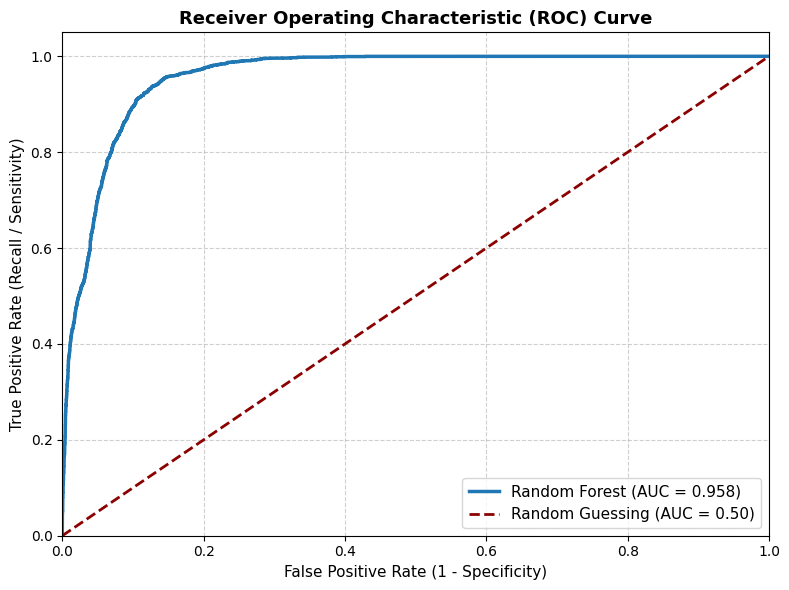

In [117]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Prepare Features (X) and Target (y)
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df_balanced.columns else 'previously_contacted'
cols_to_drop = [target_col, 'features_used_for_model']
existing_drops = [c for c in cols_to_drop if c in df_balanced.columns]

X = df_balanced.drop(columns=existing_drops).select_dtypes(include=['number', 'bool']).astype(float)
y = df_balanced[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = RandomForestClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 3. Predict Probabilities for the Positive Class ('Yes' / 1)
y_probs = model.predict_proba(X_test)[:, 1]

# 4. Calculate ROC Curve Points & AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 5. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='darkred', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 13. Confusion Matrix

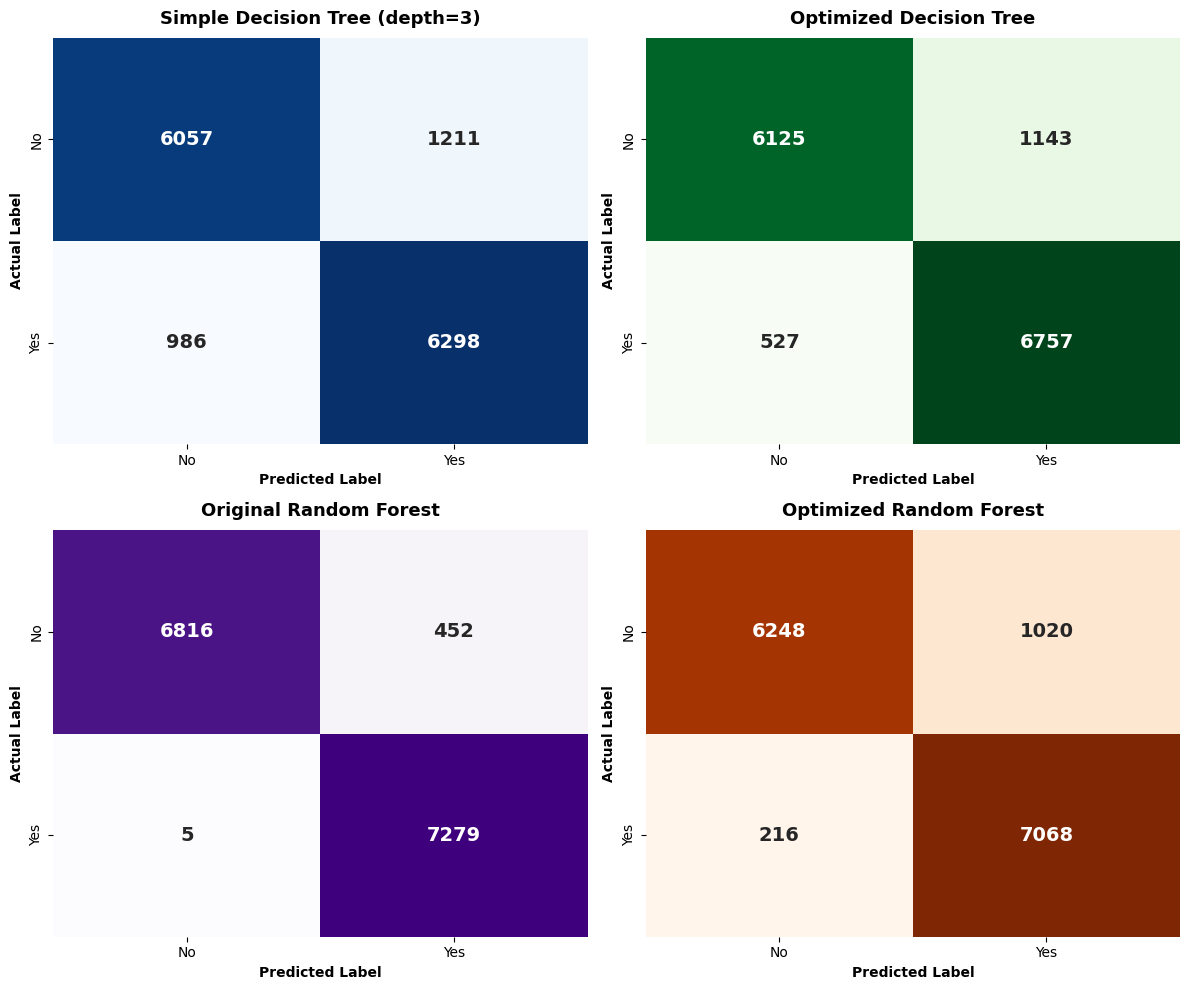

In [120]:


# 1. Prepare Features (X) and Target (y)
target_col = 'previously_contacted_yes' if 'previously_contacted_yes' in df_balanced.columns else 'previously_contacted'
cols_to_drop = [target_col, 'features_used_for_model']
existing_drops = [c for c in cols_to_drop if c in df_balanced.columns]

X = df_balanced.drop(columns=existing_drops).select_dtypes(include=['number', 'bool']).astype(float)
y = df_balanced[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define the 4 Models and distinct color palettes
models = {
    'Simple Decision Tree (depth=3)': (DecisionTreeClassifier(max_depth=3, random_state=42), 'Blues'),
    'Optimized Decision Tree': (DecisionTreeClassifier(max_depth=6, min_samples_split=10, min_samples_leaf=5, random_state=42), 'Greens'),
    'Original Random Forest': (RandomForestClassifier(random_state=42), 'Purples'),
    'Optimized Random Forest': (RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_split=5, max_features='sqrt', random_state=42, n_jobs=-1), 'Oranges')
}

# 3. Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

class_names = ['No', 'Yes']

# 4. Train, predict, and plot each matrix
for idx, (model_name, (model, cmap_color)) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot colorful heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap_color,
        cbar=False,
        ax=axes[idx],
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 14, "weight": "bold"}
    )

    axes[idx].set_title(model_name, fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Actual Label', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()